![JohnSnowLabs](https://sparknlp.org/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/spark-nlp/blob/master/examples/python/annotation/text/english/vector-db/VectorDBConnector_Pinecone_Demo.ipynb)

# VectorDBConnector: Store Embeddings in Pinecone with Spark NLP

This notebook demonstrates how to use the **`VectorDBConnector`** annotator to take sentence embeddings produced by Spark NLP and upsert them directly into a [Pinecone](https://www.pinecone.io/) vector database all within a single Spark ML `Pipeline`.

## Prerequisites Checklist

Before running this notebook make sure you have:

1. **Pinecone account & API key**: sign up at [pinecone.io](https://www.pinecone.io/)  
2. **Index already created**: the `VectorDBConnector` does **not** create indexes.  
   Create one at [app.pinecone.io](https://app.pinecone.io/) matching your embedding dimension (768 for `sent_small_bert_L2_768`).  
3. **API key configured**: either:
   - Pass it via Spark config: `spark.jsl.settings.vectordb.api.key`

## 0: Setup

In [ ]:
# Install Spark NLP (run only on Colab / fresh environments)
!wget https://setup.johnsnowlabs.com/colab.sh -O - |

In [ ]:
import sparknlp

# Pass your Pinecone API key via the vectordb.api.key Spark config
PINECONE_API_KEY = "" # <-- replace with your key

spark = sparknlp.start(params={
    "spark.jsl.settings.vectordb.api.key": PINECONE_API_KEY,
})

print("Spark NLP version:", sparknlp.version())
print("Apache Spark version:", spark.version)


## 1: Prepare Sample Data

We create a small DataFrame with an **ID**, **text**, and a **category** column.  
The `VectorDBConnector` can forward any of these columns as vector metadata to Pinecone.

In [6]:
data = spark.createDataFrame([
    ("doc_001", "Spark NLP is an open-source library for state-of-the-art NLP.", "technology"),
    ("doc_002", "Vector databases enable fast semantic similarity search.", "technology"),
    ("doc_003", "Machine learning models require high-quality training data.", "data-science"),
    ("doc_004", "Transfer learning allows reusing knowledge across tasks.", "data-science"),
    ("doc_005", "Kubernetes orchestrates containerized applications at scale.", "devops"),
    ("doc_006", "CI/CD pipelines automate software delivery workflows.", "devops"),
    ("doc_007", "Retrieval-augmented generation improves LLM accuracy.", "ai"),
    ("doc_008", "Embedding models convert text into dense numerical vectors.", "ai"),
]).toDF("doc_id", "text", "category")

data.show(truncate=False)

+-------+-------------------------------------------------------------+------------+
|doc_id |text                                                         |category    |
+-------+-------------------------------------------------------------+------------+
|doc_001|Spark NLP is an open-source library for state-of-the-art NLP.|technology  |
|doc_002|Vector databases enable fast semantic similarity search.     |technology  |
|doc_003|Machine learning models require high-quality training data.  |data-science|
|doc_004|Transfer learning allows reusing knowledge across tasks.     |data-science|
|doc_005|Kubernetes orchestrates containerized applications at scale. |devops      |
|doc_006|CI/CD pipelines automate software delivery workflows.        |devops      |
|doc_007|Retrieval-augmented generation improves LLM accuracy.        |ai          |
|doc_008|Embedding models convert text into dense numerical vectors.  |ai          |
+-------+--------------------------------------------------------

## 2:  Build the Pipeline

The pipeline consists of three stages: `DocumentAssembler`, which converts the raw `text` column into a Spark NLP `DOCUMENT` annotation; `BertSentenceEmbeddings`, which generates a 768-dimensional embedding for each document; and `VectorDBConnector`, which upserts the embeddings along with their IDs and metadata to Pinecone.


In [7]:
from sparknlp.base import DocumentAssembler
from sparknlp.annotator import BertSentenceEmbeddings
from pyspark.ml import Pipeline

document_assembler = DocumentAssembler() \
    .setInputCol("text") \
    .setOutputCol("document")

sentence_embeddings = BertSentenceEmbeddings.pretrained("sent_small_bert_L2_768") \
    .setInputCols(["document"]) \
    .setOutputCol("sentence_embeddings")


sent_small_bert_L2_768 download started this may take some time.
Approximate size to download 139.6 MB
[OK!]


**Important**: The embedding dimension must match the dimension configured in your Pinecone index.

In [8]:
sentence_embeddings.getDimension()

768

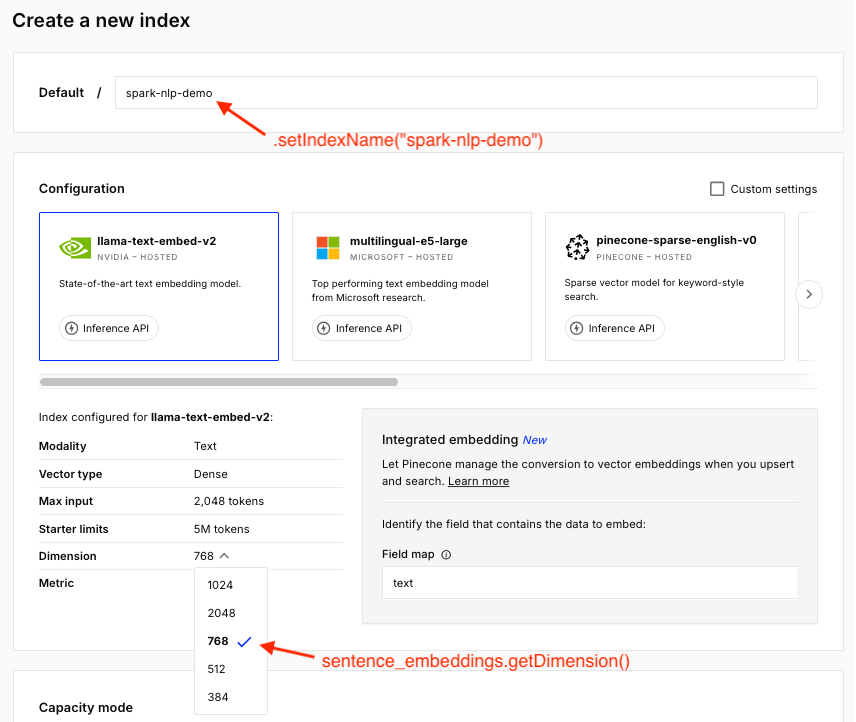

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `provider` | `str` | `"pinecone"` | Vector database provider |
| `indexName` | `str` | (required) | Name of the Pinecone index (must already exist) |
| `namespace` | `str` | `""` | Namespace/partition within the index |
| `idColumn` | `str` |   | Column to use as vector ID; UUIDs are generated if omitted |
| `metadataColumns` | `list[str]` | `[]` | Columns whose values are stored alongside each vector |
| `batchSize` | `int` | `100` | Vectors per Pinecone upsert call (1–1000) |

In [9]:
from sparknlp.annotator import VectorDBConnector

vector_db = VectorDBConnector() \
    .setInputCols(["document", "sentence_embeddings"]) \
    .setOutputCol("vectordb_result") \
    .setProvider("pinecone") \
    .setIndexName("spark-nlp-demo") \
    .setIdColumn("doc_id") \
    .setMetadataColumns(["text", "category"]) \
    .setBatchSize(100)


Assemble and Run the Pipeline

In [10]:
pipeline = Pipeline(stages=[
    document_assembler,
    sentence_embeddings,
    vector_db
])

result = pipeline.fit(data).transform(data)

## 3: Inspect the Results

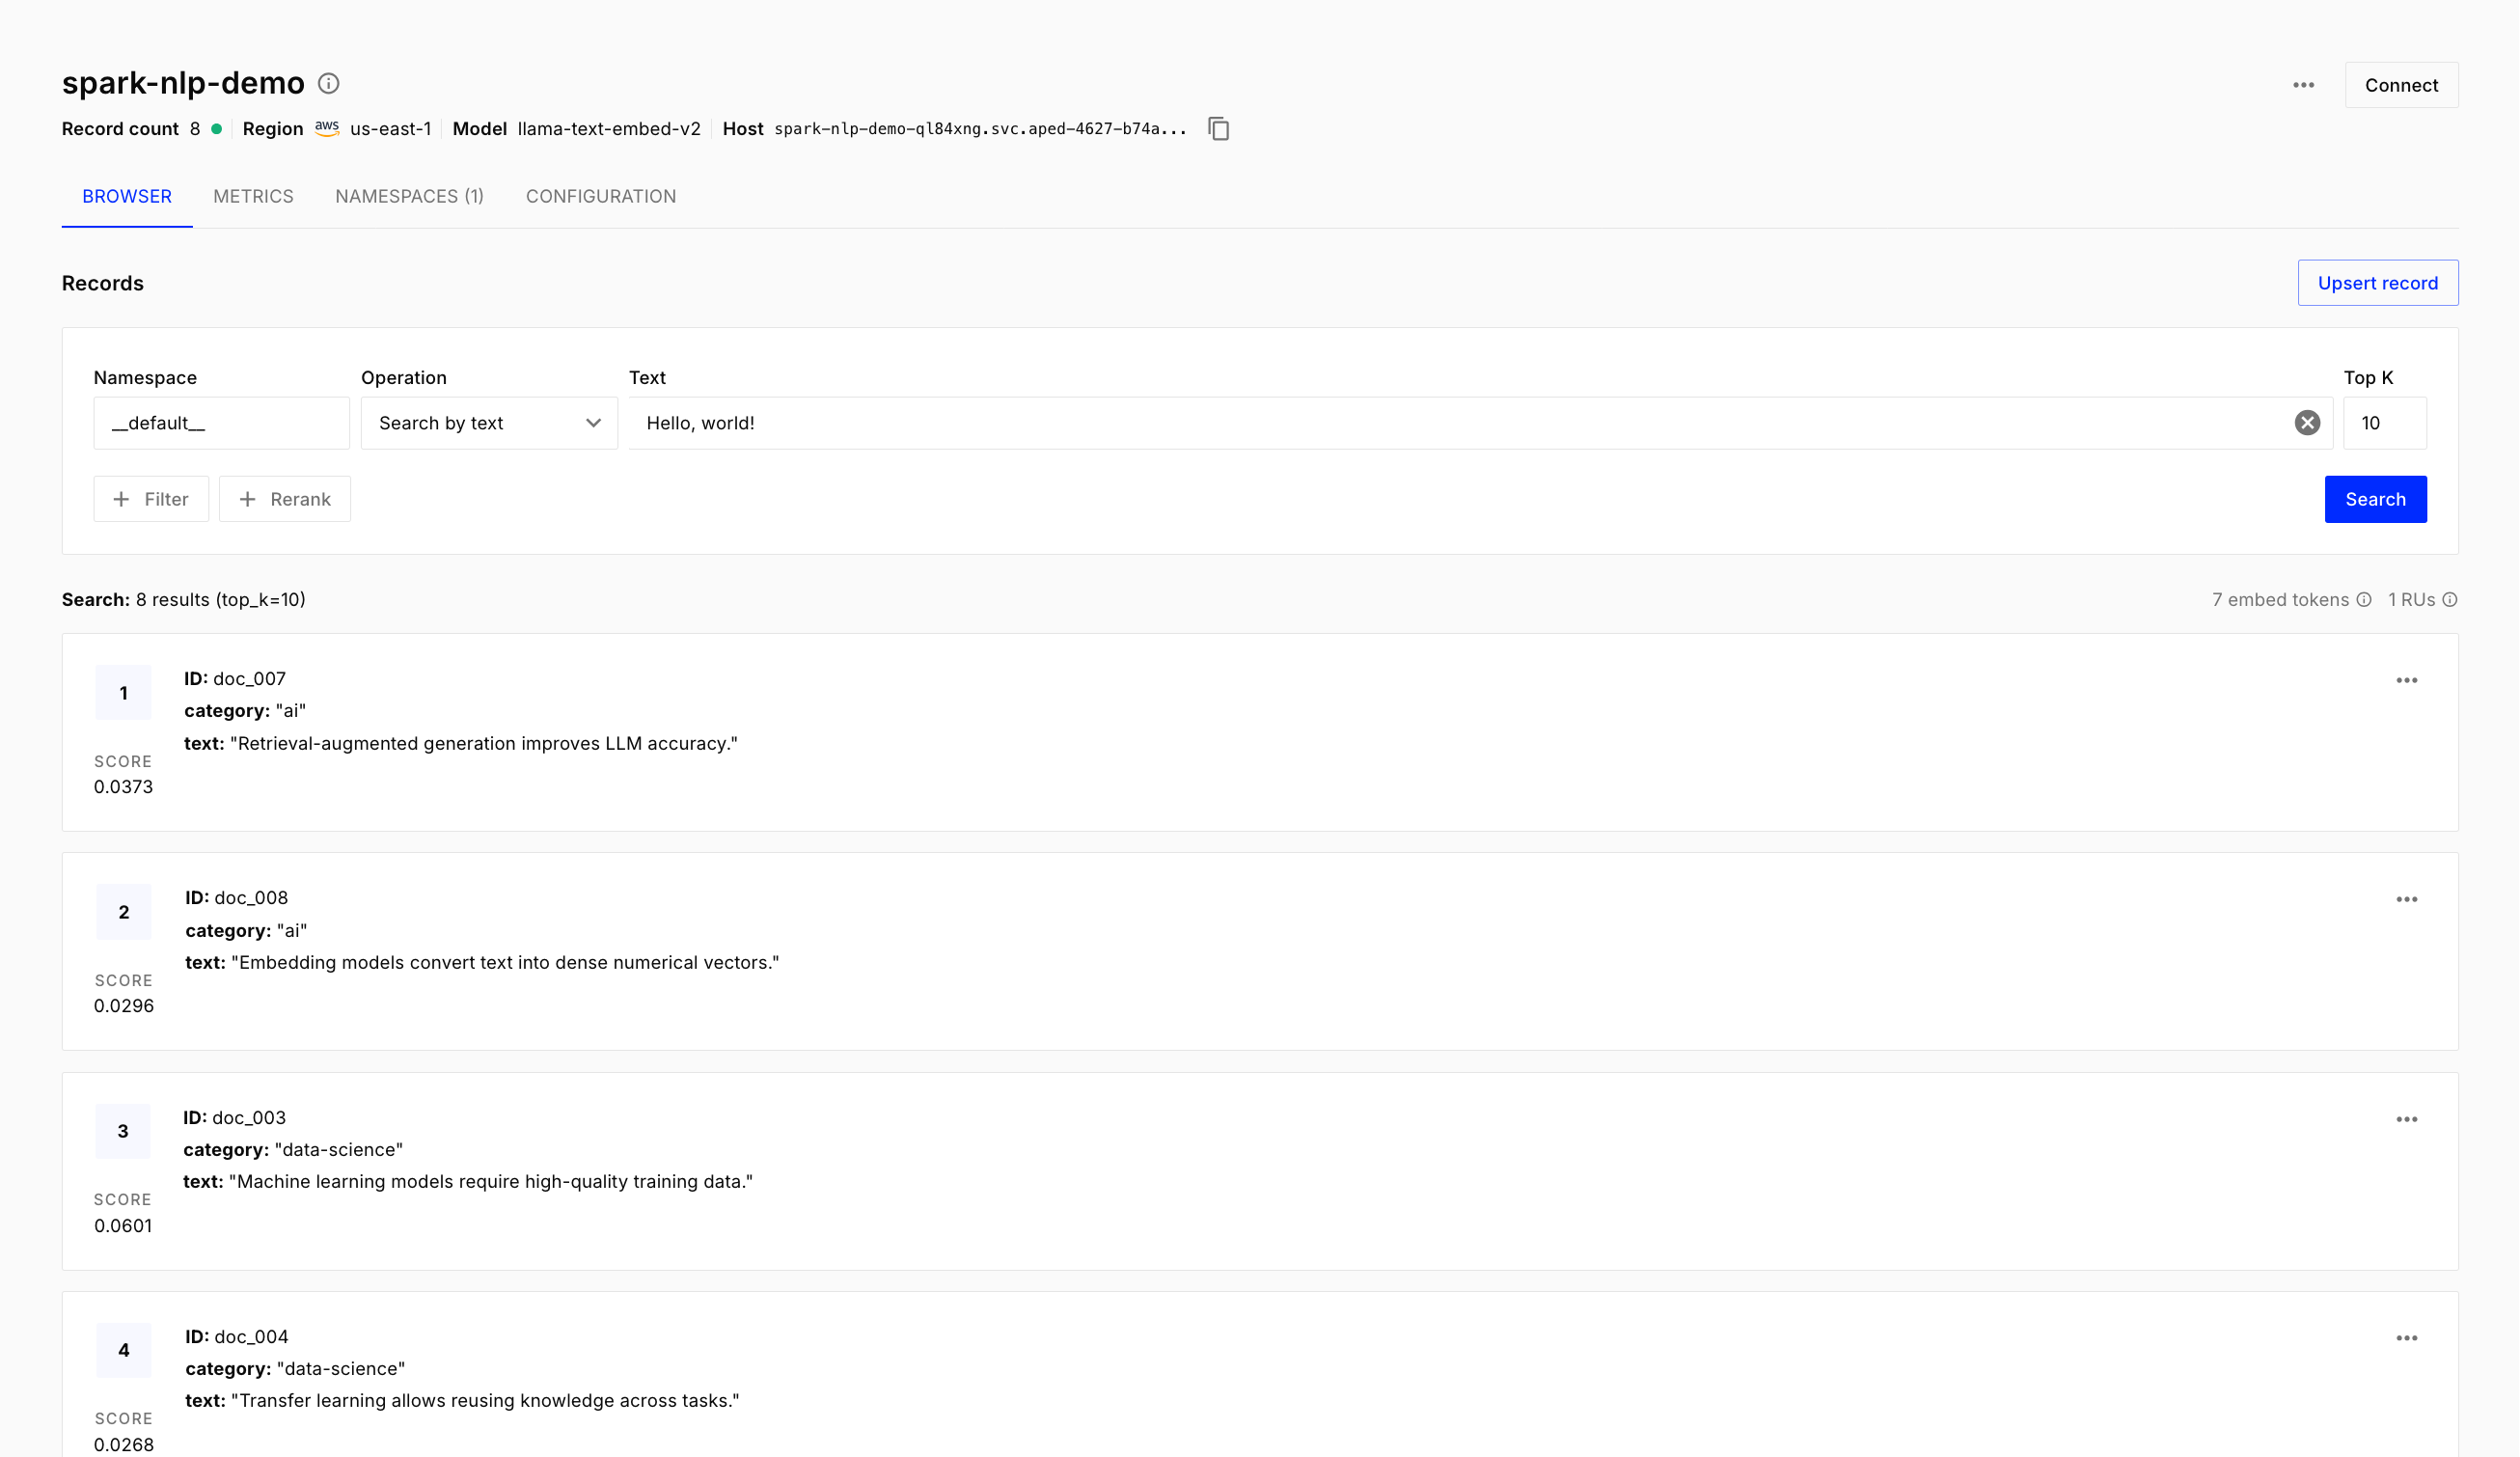

Each row now contains a `vectordb_result` annotation.  
The annotation's `result` field holds the vector ID, and its `metadata` map includes:
- `vectordb_status`: `"upserted"` on success
- `provider`: `"pinecone"`

In [11]:
result.select("doc_id", "category", "vectordb_result").show(truncate=False)

+-------+------------+----------------------------------------------------------------------------------------------------+
|doc_id |category    |vectordb_result                                                                                     |
+-------+------------+----------------------------------------------------------------------------------------------------+
|doc_001|technology  |[{document, 0, 60, doc_001, {sentence -> 0, vectordb_status -> upserted, provider -> pinecone}, []}]|
|doc_002|technology  |[{document, 0, 55, doc_002, {sentence -> 0, vectordb_status -> upserted, provider -> pinecone}, []}]|
|doc_003|data-science|[{document, 0, 58, doc_003, {sentence -> 0, vectordb_status -> upserted, provider -> pinecone}, []}]|
|doc_004|data-science|[{document, 0, 55, doc_004, {sentence -> 0, vectordb_status -> upserted, provider -> pinecone}, []}]|
|doc_005|devops      |[{document, 0, 59, doc_005, {sentence -> 0, vectordb_status -> upserted, provider -> pinecone}, []}]|
|doc_006

## 4: Variations & Tips

### 4.1: Auto-generated UUIDs

If you don't have a natural ID column, simply omit `setIdColumn`.  
The connector will generate a UUID for every vector automatically.

In [ ]:
vector_db_auto_id = VectorDBConnector() \
    .setInputCols(["document", "sentence_embeddings"]) \
    .setOutputCol("vectordb_result") \
    .setProvider("pinecone") \
    .setIndexName("spark-nlp-demo") \
    .setNamespace("auto-id-demo")
    # No setIdColumn — UUIDs will be generated

pipeline_auto = Pipeline(stages=[
    document_assembler,
    sentence_embeddings,
    vector_db_auto_id
])

result_auto = pipeline_auto.fit(data).transform(data)


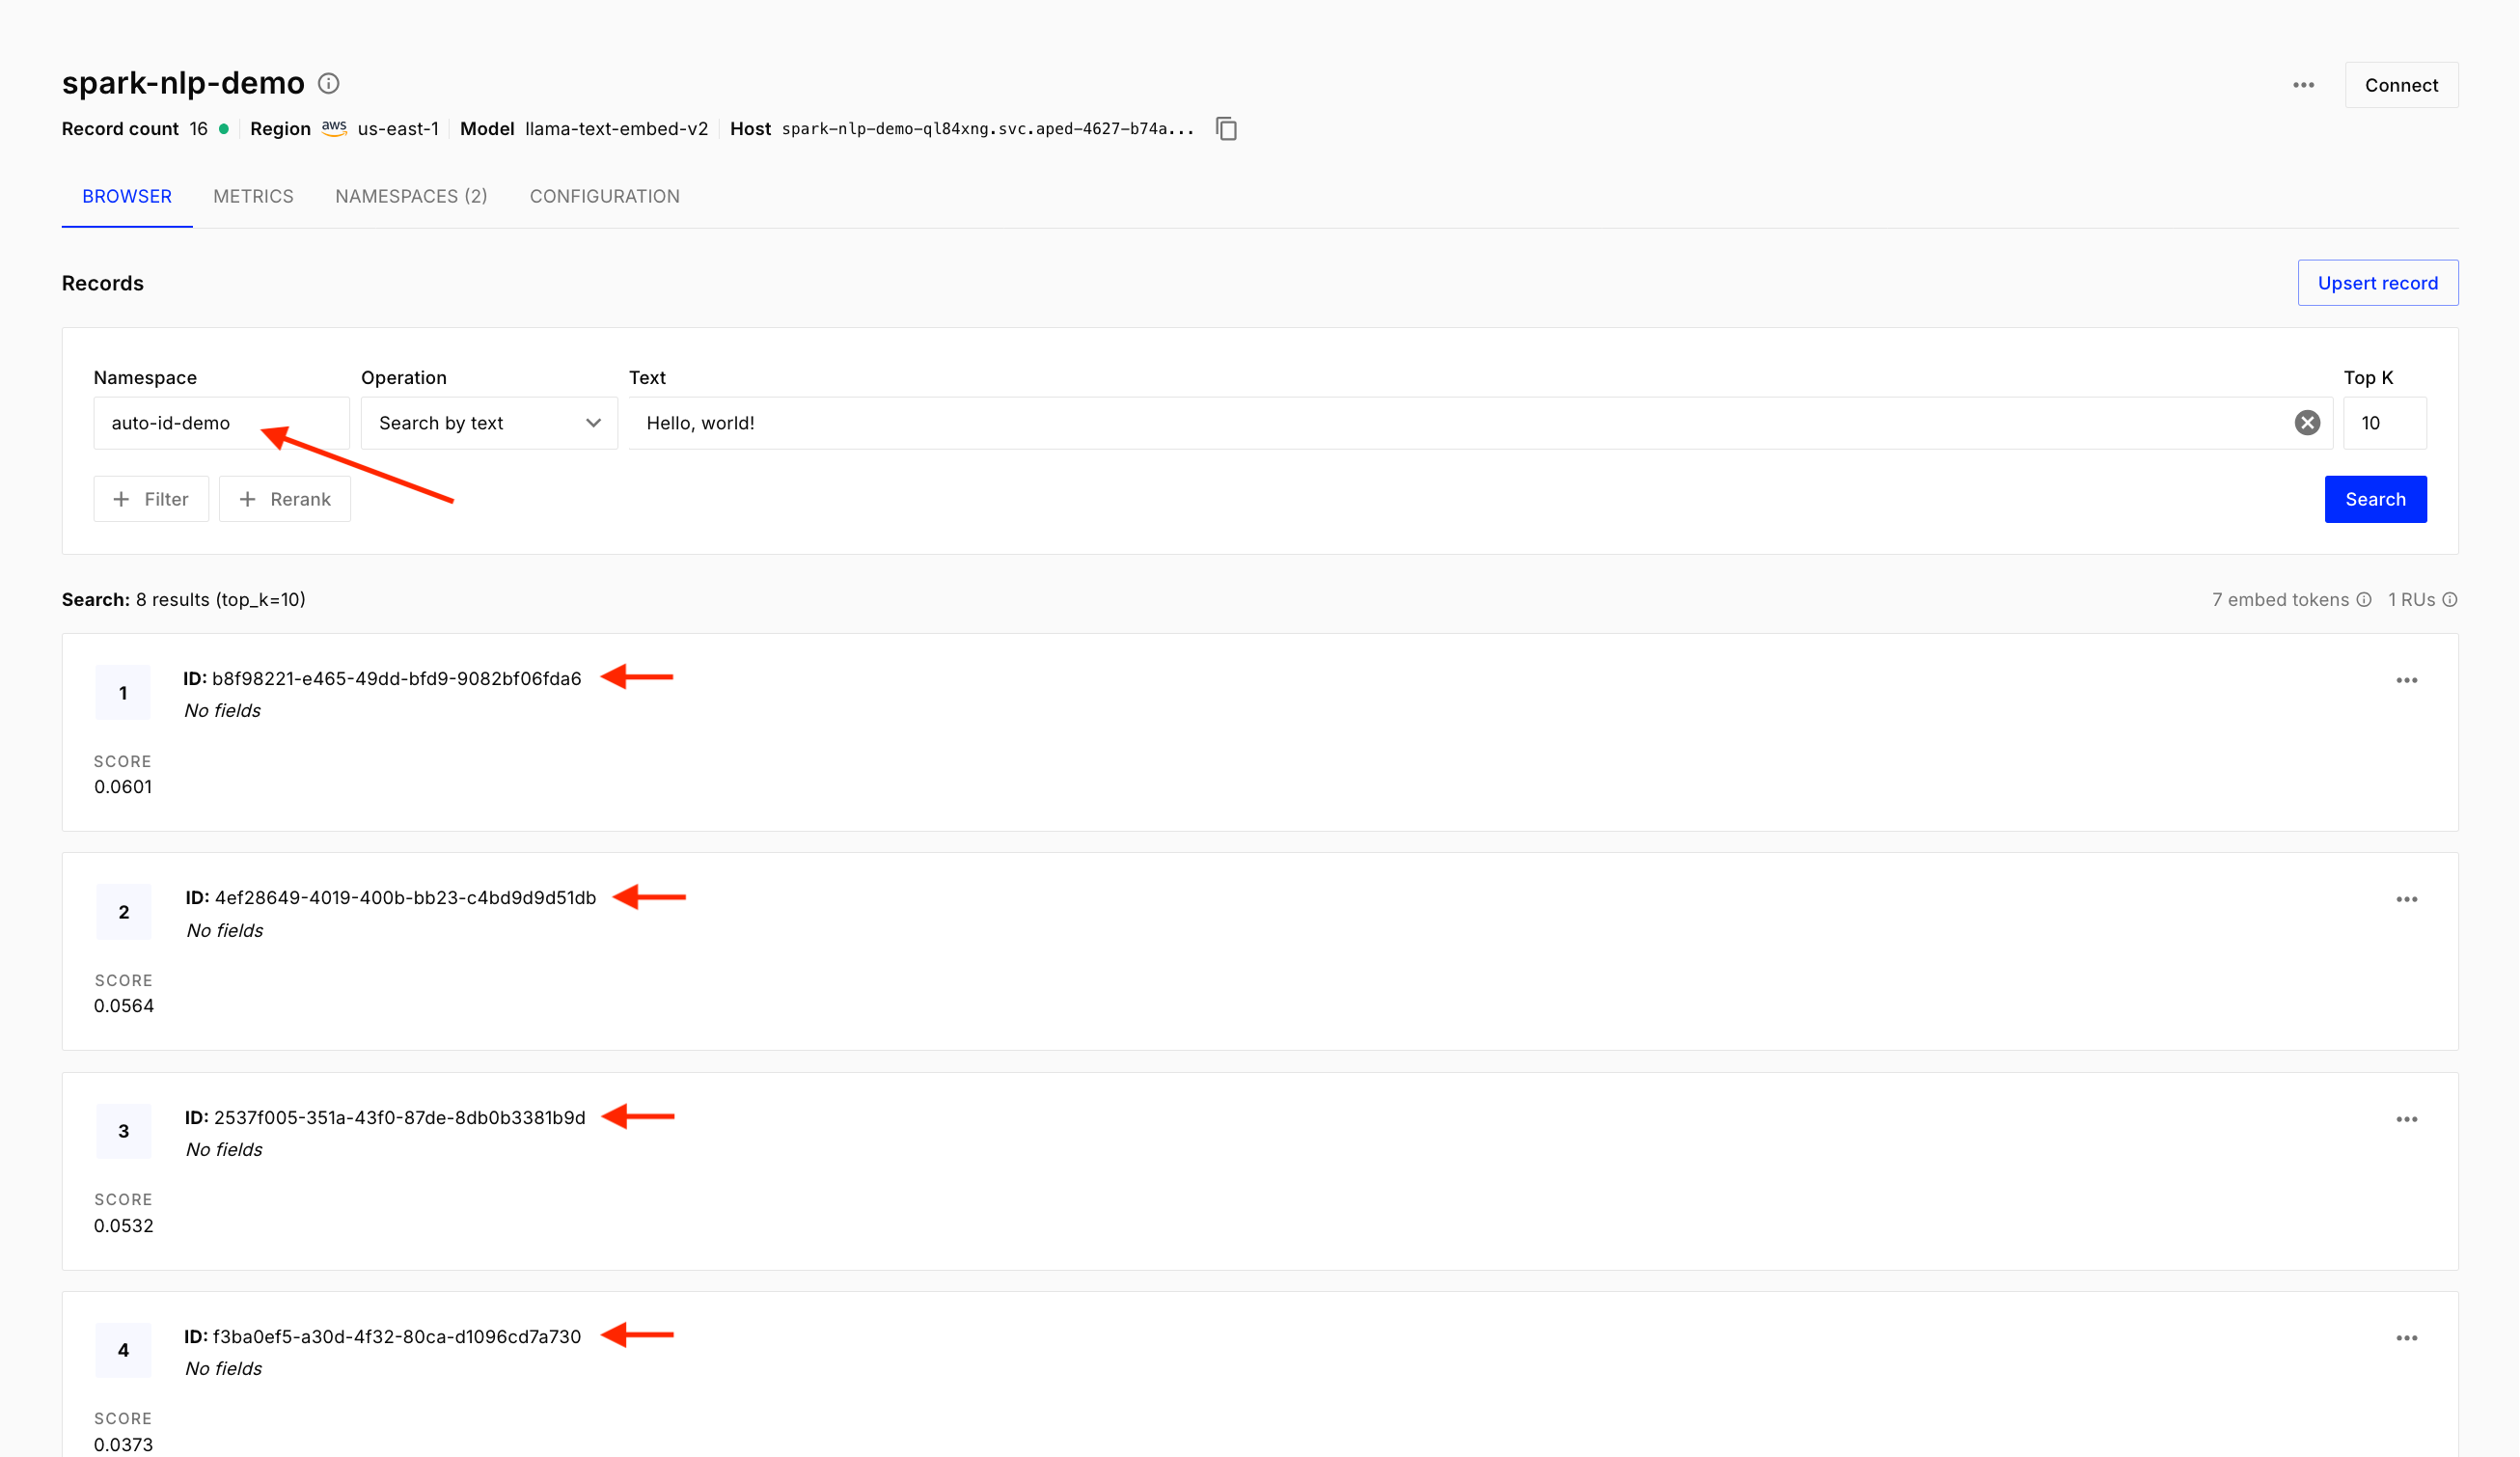

In [13]:
result_auto.select("doc_id", "vectordb_result.result").show(truncate=False)

+-------+--------------------------------------+
|doc_id |result                                |
+-------+--------------------------------------+
|doc_001|[4ef28649-4019-400b-bb23-c4bd9d9d51db]|
|doc_002|[e53ab993-8cd2-4f4d-925e-f60aaad981ad]|
|doc_003|[b8f98221-e465-49dd-bfd9-9082bf06fda6]|
|doc_004|[9b9e05ac-25fb-4775-a1e4-4d8d7b2166bf]|
|doc_005|[2537f005-351a-43f0-87de-8db0b3381b9d]|
|doc_006|[2ca56af2-c120-4f71-bd6d-e7d5ba822404]|
|doc_007|[f3ba0ef5-a30d-4f32-80ca-d1096cd7a730]|
|doc_008|[61a3f1cd-78cb-42df-9436-4f36833a8502]|
+-------+--------------------------------------+



### 4.2: Large-Scale Ingestion with Custom Batch Size

For bigger datasets, tune `batchSize` (max 1000) to reduce network round-trips.

> **Tip:** A batch size of 100–200 works well for most use cases. Going higher reduces HTTP calls but increases per-request payload.

In [15]:
# Generate a larger dataset
large_data = spark.createDataFrame([
    (f"id_{i}",
     f"This is document number {i} with some content for testing vector ingestion.",
     f"category_{i % 5}")
    for i in range(1, 501)
]).toDF("doc_id", "text", "category")

print(f"Total documents: {large_data.count()}")
large_data.show(5, truncate=False)


Total documents: 500
+------+-------------------------------------------------------------------------+----------+
|doc_id|text                                                                     |category  |
+------+-------------------------------------------------------------------------+----------+
|id_1  |This is document number 1 with some content for testing vector ingestion.|category_1|
|id_2  |This is document number 2 with some content for testing vector ingestion.|category_2|
|id_3  |This is document number 3 with some content for testing vector ingestion.|category_3|
|id_4  |This is document number 4 with some content for testing vector ingestion.|category_4|
|id_5  |This is document number 5 with some content for testing vector ingestion.|category_0|
+------+-------------------------------------------------------------------------+----------+
only showing top 5 rows



In [ ]:
vector_db_large = VectorDBConnector() \
    .setInputCols(["document", "sentence_embeddings"]) \
    .setOutputCol("vectordb_result") \
    .setProvider("pinecone") \
    .setIndexName("spark-nlp-demo") \
    .setNamespace("large-batch-demo") \
    .setIdColumn("doc_id") \
    .setMetadataColumns(["text", "category"]) \
    .setBatchSize(200)  # larger batches for bulk ingestion

pipeline_large = Pipeline(stages=[
    document_assembler,
    sentence_embeddings,
    vector_db_large
])

result_large = pipeline_large.fit(large_data).transform(large_data)


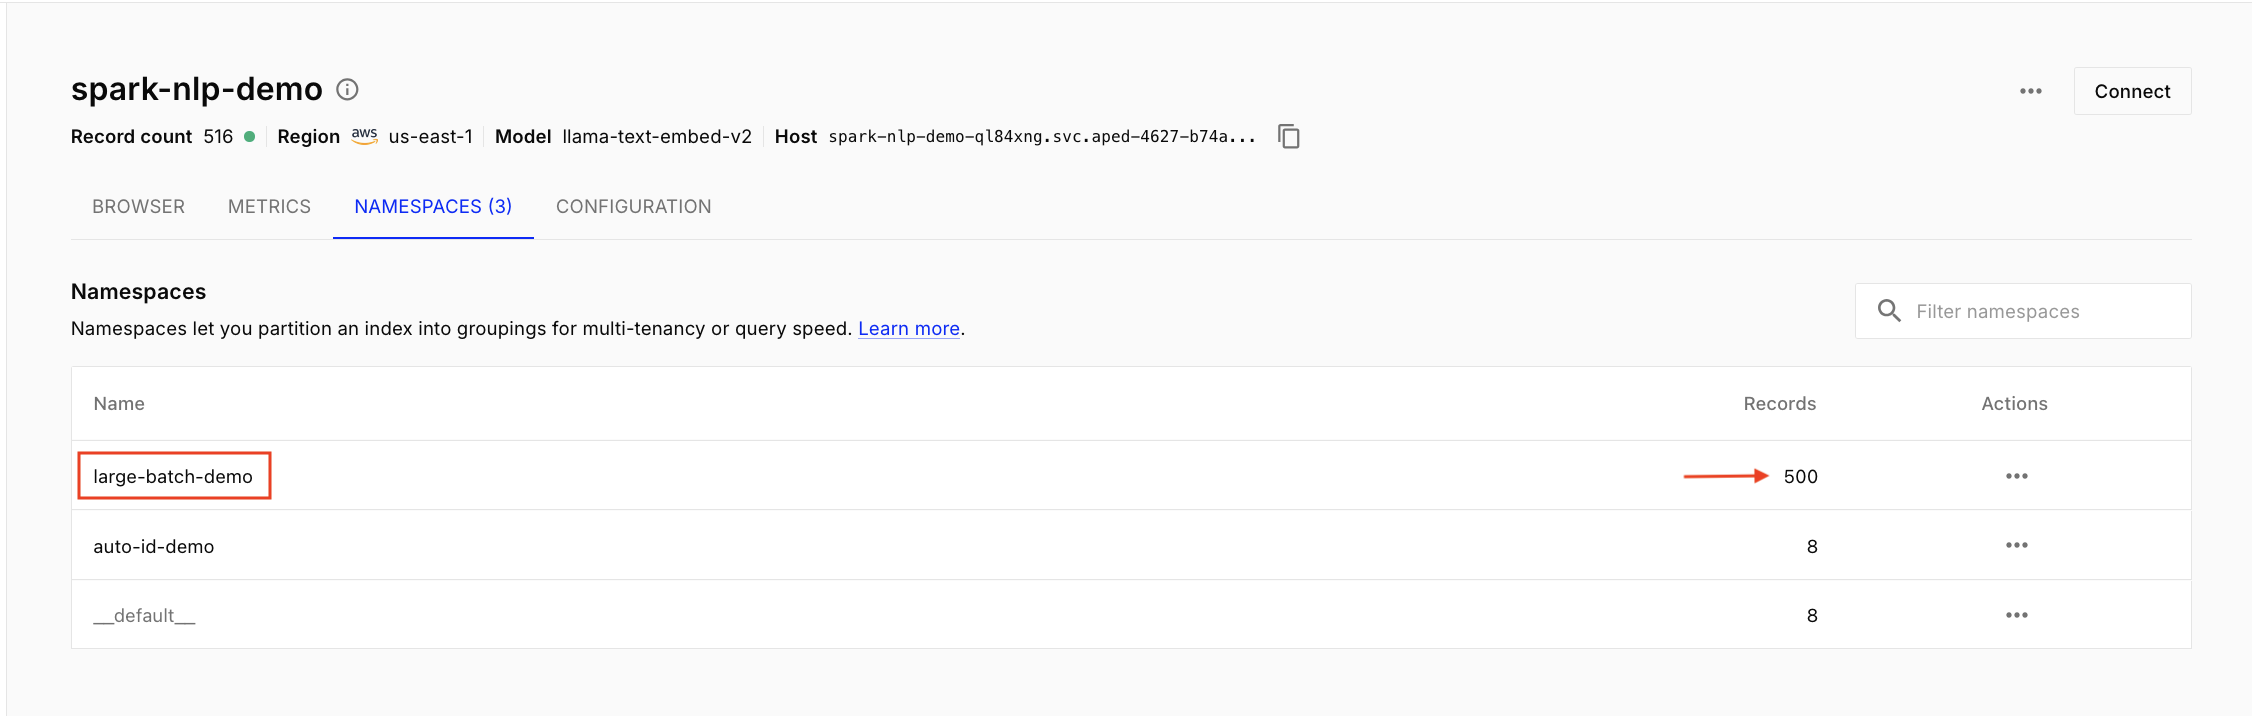

In [16]:
print(f"Rows processed: {result_large.count()}")

Rows processed: 500


In [18]:
spark.stop()